<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TugasCrossValidation.ipynb
## K-Fold Cross Validation – Prediksi Keselamatan Penumpang Titanic



---
## 1. Import Library

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Validasi
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print(' Semua library berhasil diimport!')

 Semua library berhasil diimport!


---
## 2. Load Dataset



In [74]:
from google.colab import drive
drive.mount('/content/drive')

# Sesuaikan path dengan lokasi file di Google Drive
TRAIN_PATH  = '/content/drive/MyDrive/ML/Dataset/titanic/train.csv'
TEST_PATH   = '/content/drive/MyDrive/ML/Dataset/titanic/test.csv'
LABEL_PATH  = '/content/drive/MyDrive/ML/Dataset/titanic/gender_submission.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df_label = pd.read_csv(LABEL_PATH)   # label untuk df_test

print(f'Train  : {df_train.shape}  → digunakan untuk K-Fold CV')
print(f'Test   : {df_test.shape}   → digunakan untuk Final Testing')
print(f'Label  : {df_label.shape}  → label test')

print('\n--- 5 Baris Pertama Train ---')
df_train.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train  : (891, 12)  → digunakan untuk K-Fold CV
Test   : (418, 11)   → digunakan untuk Final Testing
Label  : (418, 2)  → label test

--- 5 Baris Pertama Train ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 3. Eksplorasi Data (EDA)

In [75]:
print('=== INFO DATASET TRAIN ===')
df_train.info()
print('\n=== STATISTIK DESKRIPTIF ===')
df_train.describe()

=== INFO DATASET TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== STATISTIK DESKRIPTIF ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [76]:
print('=== MISSING VALUES – TRAIN ===')
missing_train = df_train.isnull().sum()
missing_train = missing_train[missing_train > 0]
for col, cnt in missing_train.items():
    print(f'  {col:12s}: {cnt:3d} ({cnt/len(df_train)*100:.1f}%)')

print('\n=== MISSING VALUES – TEST ===')
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0]
for col, cnt in missing_test.items():
    print(f'  {col:12s}: {cnt:3d} ({cnt/len(df_test)*100:.1f}%)')

print('\n=== DISTRIBUSI TARGET (TRAIN) ===')
vc = df_train['Survived'].value_counts()
for k, v in vc.items():
    label = 'Selamat' if k == 1 else 'Tidak Selamat'
    print(f'  {k} ({label}): {v} ({v/len(df_train)*100:.1f}%)')

=== MISSING VALUES – TRAIN ===
  Age         : 177 (19.9%)
  Cabin       : 687 (77.1%)
  Embarked    :   2 (0.2%)

=== MISSING VALUES – TEST ===
  Age         :  86 (20.6%)
  Fare        :   1 (0.2%)
  Cabin       : 327 (78.2%)

=== DISTRIBUSI TARGET (TRAIN) ===
  0 (Tidak Selamat): 549 (61.6%)
  1 (Selamat): 342 (38.4%)


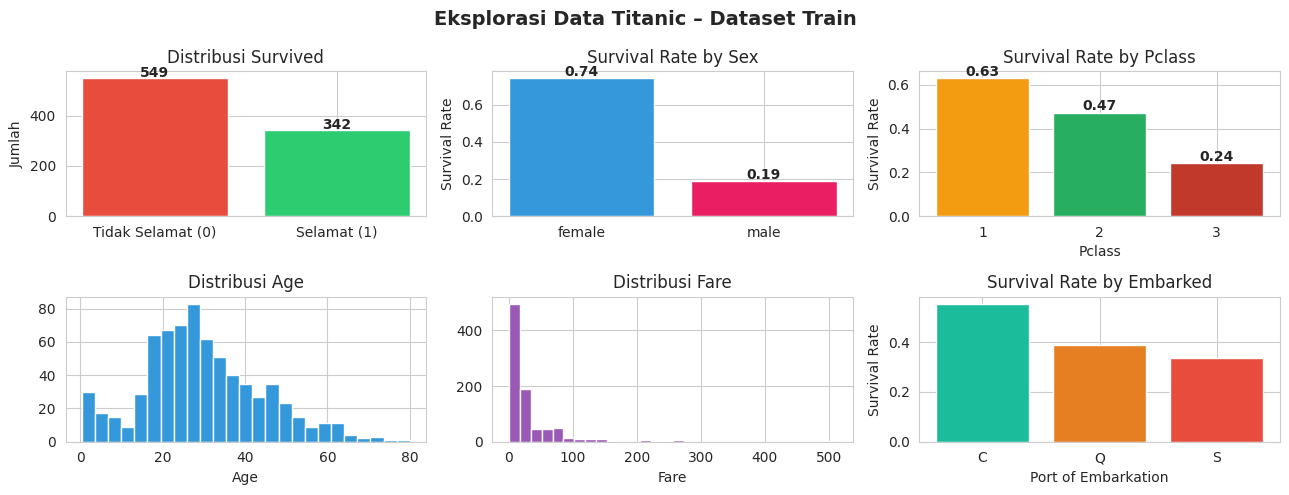

EDA selesai!


In [77]:
# Visualisasi distribusi kelas dan ftur utama
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
fig.suptitle('Eksplorasi Data Titanic – Dataset Train', fontsize=14, fontweight='bold')

# 1. Distribusi Survived
vc = df_train['Survived'].value_counts()
axes[0,0].bar(['Tidak Selamat (0)', 'Selamat (1)'], vc.values, color=['#e74c3c','#2ecc71'])
axes[0,0].set_title('Distribusi Survived')
axes[0,0].set_ylabel('Jumlah')
for i, v in enumerate(vc.values):
    axes[0,0].text(i, v+5, str(v), ha='center', fontweight='bold')

# 2. Survived vs Sex
sex_surv = df_train.groupby('Sex')['Survived'].mean()
axes[0,1].bar(sex_surv.index, sex_surv.values, color=['#3498db','#e91e63'])
axes[0,1].set_title('Survival Rate by Sex')
axes[0,1].set_ylabel('Survival Rate')
for i, (k, v) in enumerate(sex_surv.items()):
    axes[0,1].text(i, v+0.01, f'{v:.2f}', ha='center', fontweight='bold')

# 3. Survived vs Pclass
pclass_surv = df_train.groupby('Pclass')['Survived'].mean()
axes[0,2].bar(pclass_surv.index.astype(str), pclass_surv.values, color=['#f39c12','#27ae60','#c0392b'])
axes[0,2].set_title('Survival Rate by Pclass')
axes[0,2].set_ylabel('Survival Rate')
axes[0,2].set_xlabel('Pclass')
for i, (k, v) in enumerate(pclass_surv.items()):
    axes[0,2].text(i, v+0.01, f'{v:.2f}', ha='center', fontweight='bold')

# 4. Distribusi Age
df_train['Age'].dropna().hist(ax=axes[1,0], bins=25, color='#3498db', edgecolor='white')
axes[1,0].set_title('Distribusi Age')
axes[1,0].set_xlabel('Age')

# 5. Distribusi Fare
df_train['Fare'].hist(ax=axes[1,1], bins=30, color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Distribusi Fare')
axes[1,1].set_xlabel('Fare')

# 6. Survived vs Embarked
emb_surv = df_train.groupby('Embarked')['Survived'].mean().dropna()
axes[1,2].bar(emb_surv.index, emb_surv.values, color=['#1abc9c','#e67e22','#e74c3c'])
axes[1,2].set_title('Survival Rate by Embarked')
axes[1,2].set_ylabel('Survival Rate')
axes[1,2].set_xlabel('Port of Embarkation')

plt.tight_layout()
plt.savefig('eda_titanic.png', bbox_inches='tight')
plt.show()
print('EDA selesai!')

---
## 4. Praproses Data

Praproses dilakukan **terpisah** pada train dan test untuk menghindari *data leakage*.  
Namun parameter pengisian (median, modus) dihitung dari **train** saja, lalu diterapkan ke test.

In [78]:
def extract_title(name):
    """Ekstrak title dari kolom Name."""
    title = name.split(',')[1].split('.')[0].strip()
    rare = {'Lady','Countess','Capt','Col','Don','Dr',
            'Major','Rev','Sir','Jonkheer','Dona'}
    if title in rare:
        return 'Rare'
    elif title == 'Mlle':
        return 'Miss'
    elif title == 'Ms':
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    return title

def preprocess(df, fit_params=None, is_train=True):
    """
    Praproses dataset Titanic.
    fit_params: dict parameter dari train (untuk diterapkan ke test)
    is_train: True jika dataset train
    """
    df = df.copy()

    # --- Feature Engineering ---
    df['Title']      = df['Name'].apply(extract_title)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # --- Imputasi (hitung dari train, terapkan ke test) ---
    if is_train:
        age_median  = df['Age'].median()
        fare_median = df['Fare'].median()
        emb_mode    = df['Embarked'].mode()[0]
        params = {
            'age_median' : age_median,
            'fare_median': fare_median,
            'emb_mode'   : emb_mode
        }
    else:
        params      = fit_params
        age_median  = params['age_median']
        fare_median = params['fare_median']
        emb_mode    = params['emb_mode']

    df['Age']      = df['Age'].fillna(age_median)
    df['Fare']     = df['Fare'].fillna(fare_median)
    df['Embarked'] = df['Embarked'].fillna(emb_mode)

    # --- Drop kolom tidak diperlukan ---
    df.drop(columns=['PassengerId','Name','Ticket','Cabin'], inplace=True)

    # --- Binning Age dan Fare ---
    df['AgeBin']  = pd.cut(df['Age'],
                            bins=[0,12,18,35,60,np.inf],
                            labels=[0,1,2,3,4]).astype(int)
    df['FareBin'] = pd.qcut(df['Fare'], q=4,
                             labels=[0,1,2,3]).astype(int)

    # --- Encoding kategorikal ---
    df['Sex']      = df['Sex'].map({'male':0,'female':1})
    df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

    title_map = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4}
    df['Title'] = df['Title'].map(title_map).fillna(4).astype(int)

    # --- Hapus kolom mentah yang sudah di-bin ---
    df.drop(columns=['Age','Fare'], inplace=True)

    if is_train:
        return df, params
    else:
        return df

# --- Jalankan praproses ---
df_train_proc, fit_params = preprocess(df_train, is_train=True)
df_test_proc              = preprocess(df_test,  fit_params=fit_params, is_train=False)

print('=== Hasil Praproses TRAIN ===')
print(df_train_proc.shape)
print(df_train_proc.head())
print('\n=== Hasil Praproses TEST ===')
print(df_test_proc.shape)
print(df_test_proc.head())

=== Hasil Praproses TRAIN ===
(891, 11)
   Survived  Pclass  Sex  SibSp  Parch  Embarked  Title  FamilySize  IsAlone  \
0         0       3    0      1      0         0      0           2        0   
1         1       1    1      1      0         1      2           2        0   
2         1       3    1      0      0         0      1           1        1   
3         1       1    1      1      0         0      2           2        0   
4         0       3    0      0      0         0      0           1        1   

   AgeBin  FareBin  
0       2        0  
1       3        3  
2       2        1  
3       2        3  
4       2        1  

=== Hasil Praproses TEST ===
(418, 10)
   Pclass  Sex  SibSp  Parch  Embarked  Title  FamilySize  IsAlone  AgeBin  \
0       3    0      0      0         2      0           1        1       2   
1       3    1      1      0         0      2           2        0       3   
2       2    0      0      0         2      0           1        1       4   
3

In [79]:
# --- Pisahkan fitur dan target ---

# Train: X dan y dari train.csv
X_train = df_train_proc.drop(columns=['Survived'])
y_train = df_train_proc['Survived']

# Test: X dari test.csv, y dari gender_submission.csv
X_test  = df_test_proc
y_test  = df_label['Survived']

print(f'X_train : {X_train.shape}  | y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   | y_test  : {y_test.shape}')
print(f'\nFitur yang digunakan: {list(X_train.columns)}')

# --- Cek apakah ada NaN yang tersisa ---
print(f'\nNaN di X_train: {X_train.isnull().sum().sum()}')
print(f'NaN di X_test : {X_test.isnull().sum().sum()}')

X_train : (891, 10)  | y_train : (891,)
X_test  : (418, 10)   | y_test  : (418,)

Fitur yang digunakan: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin']

NaN di X_train: 0
NaN di X_test : 0


In [80]:
# --- Standarisasi fitur (fit pada train, transform keduanya) ---
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Standarisasi selesai.')
print(f'X_train_s shape: {X_train_s.shape}')
print(f'X_test_s  shape: {X_test_s.shape}')

Standarisasi selesai.
X_train_s shape: (891, 10)
X_test_s  shape: (418, 10)


---
## 5. Definisi Model

In [81]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print('Model yang akan dievaluasi:')
for name in models:
    print(f' {name}')

Model yang akan dievaluasi:
 Logistic Regression
 Decision Tree
 Random Forest
 SVM
 KNN
 Gradient Boosting


---
## 6. K-Fold Cross Validation – K=5

**StratifiedKFold** digunakan agar setiap fold memiliki proporsi kelas yang sama dengan dataset asli.  
Metrik yang dihitung: Accuracy, Precision, Recall, F1-Score, ROC-AUC.

In [82]:
def run_kfold(models_dict, X, y, k=5, random_state=42):
    """
    Menjalankan K-Fold Cross Validation untuk semua model.
    Return: DataFrame ringkasan hasil.
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    metrics = ['accuracy','precision','recall','f1','roc_auc']
    scoring_map = {
        'accuracy' : 'accuracy',
        'precision': 'precision',
        'recall'   : 'recall',
        'f1'       : 'f1',
        'roc_auc'  : 'roc_auc'
    }

    rows = []
    print(f'\n{"="*70}')
    print(f'K-FOLD CROSS VALIDATION  (K={k})')
    print(f'{"="*70}')

    for name, model in models_dict.items():
        row = {'Model': name}
        detail_scores = {}
        for metric, scoring in scoring_map.items():
            scores = cross_val_score(model, X, y, cv=skf, scoring=scoring)
            row[f'{metric}_mean'] = scores.mean()
            row[f'{metric}_std']  = scores.std()
            detail_scores[metric] = scores
        row['_detail'] = detail_scores
        rows.append(row)

        print(f'\n  Model: {name}')
        print(f'  {"─"*55}')
        for metric in metrics:
            m = row[f'{metric}_mean']
            s = row[f'{metric}_std']
            scores_per_fold = detail_scores[metric]
            fold_str = ' | '.join([f'{v:.4f}' for v in scores_per_fold])
            print(f'  {metric.upper():12s}: {m:.4f} ± {s:.4f}  |  Tiap fold: [{fold_str}]')

    df_res = pd.DataFrame(rows)
    return df_res

# Jalankan K=5
results_k5 = run_kfold(models, X_train_s, y_train, k=5)


K-FOLD CROSS VALIDATION  (K=5)

  Model: Logistic Regression
  ───────────────────────────────────────────────────────
  ACCURACY    : 0.8092 ± 0.0076  |  Tiap fold: [0.7989 | 0.8202 | 0.8090 | 0.8034 | 0.8146]
  PRECISION   : 0.7629 ± 0.0261  |  Tiap fold: [0.7260 | 0.7903 | 0.7931 | 0.7619 | 0.7432]
  RECALL      : 0.7336 ± 0.0434  |  Tiap fold: [0.7681 | 0.7206 | 0.6765 | 0.7059 | 0.7971]
  F1          : 0.7465 ± 0.0143  |  Tiap fold: [0.7465 | 0.7538 | 0.7302 | 0.7328 | 0.7692]
  ROC_AUC     : 0.8643 ± 0.0125  |  Tiap fold: [0.8809 | 0.8670 | 0.8485 | 0.8517 | 0.8736]

  Model: Decision Tree
  ───────────────────────────────────────────────────────
  ACCURACY    : 0.8305 ± 0.0066  |  Tiap fold: [0.8324 | 0.8258 | 0.8258 | 0.8258 | 0.8427]
  PRECISION   : 0.8178 ± 0.0358  |  Tiap fold: [0.7746 | 0.8776 | 0.8364 | 0.8033 | 0.7971]
  RECALL      : 0.7247 ± 0.0654  |  Tiap fold: [0.7971 | 0.6324 | 0.6765 | 0.7206 | 0.7971]
  F1          : 0.7651 ± 0.0231  |  Tiap fold: [0.7857 | 0.735

---
## 7. K-Fold Cross Validation – K=10

In [83]:
# Jalankan K=10
results_k10 = run_kfold(models, X_train_s, y_train, k=10)


K-FOLD CROSS VALIDATION  (K=10)

  Model: Logistic Regression
  ───────────────────────────────────────────────────────
  ACCURACY    : 0.8103 ± 0.0228  |  Tiap fold: [0.8222 | 0.7753 | 0.7978 | 0.8315 | 0.7865 | 0.8202 | 0.8090 | 0.8202 | 0.8539 | 0.7865]
  PRECISION   : 0.7667 ± 0.0338  |  Tiap fold: [0.7436 | 0.7059 | 0.7500 | 0.8065 | 0.7778 | 0.8000 | 0.7576 | 0.8214 | 0.7692 | 0.7353]
  RECALL      : 0.7308 ± 0.0710  |  Tiap fold: [0.8286 | 0.7059 | 0.7059 | 0.7353 | 0.6176 | 0.7059 | 0.7353 | 0.6765 | 0.8824 | 0.7143]
  F1          : 0.7459 ± 0.0367  |  Tiap fold: [0.7838 | 0.7059 | 0.7273 | 0.7692 | 0.6885 | 0.7500 | 0.7463 | 0.7419 | 0.8219 | 0.7246]
  ROC_AUC     : 0.8660 ± 0.0337  |  Tiap fold: [0.8953 | 0.8733 | 0.8294 | 0.9051 | 0.8176 | 0.8762 | 0.8695 | 0.8329 | 0.9230 | 0.8378]

  Model: Decision Tree
  ───────────────────────────────────────────────────────
  ACCURACY    : 0.8114 ± 0.0236  |  Tiap fold: [0.8333 | 0.7978 | 0.7978 | 0.7978 | 0.7978 | 0.8202 | 0.8427 | 0

---
## 8. Perbandingan K=5 vs K=10

In [102]:
def print_comparison(res_k5, res_k10):
    metrics = ['accuracy','precision','recall','f1', 'roc_auc']
    header = f'  {"Model":22s}' + ''.join([f'{m.upper():>18s}' for m in metrics])

    for label, res in [('K=5', res_k5), ('K=10', res_k10)]:
        print(f'\n{"─"*80}')
        print(f'  HASIL K-FOLD {label}')
        print(f'{"─"*80}')
        print(header)
        for _, row in res.iterrows():
            line = f'  {row["Model"]:22s}'
            for m in metrics:
                line += f'  {row[f"{m}_mean"]:.4f}±{row[f"{m}_std"]:.4f}'
            print(line)

print_comparison(results_k5, results_k10)


────────────────────────────────────────────────────────────────────────────────
  HASIL K-FOLD K=5
────────────────────────────────────────────────────────────────────────────────
  Model                           ACCURACY         PRECISION            RECALL                F1           ROC_AUC
  Logistic Regression     0.8092±0.0076  0.7629±0.0261  0.7336±0.0434  0.7465±0.0143  0.8643±0.0125
  Decision Tree           0.8305±0.0066  0.8178±0.0358  0.7247±0.0654  0.7651±0.0231  0.8720±0.0127
  Random Forest           0.8092±0.0181  0.7683±0.0198  0.7192±0.0379  0.7427±0.0286  0.8564±0.0148
  SVM                     0.8283±0.0092  0.8233±0.0208  0.7046±0.0291  0.7588±0.0164  0.8513±0.0212
  KNN                     0.8272±0.0065  0.8002±0.0156  0.7337±0.0343  0.7648±0.0147  0.8504±0.0141
  Gradient Boosting       0.8182±0.0085  0.8044±0.0126  0.6958±0.0321  0.7457±0.0177  0.8724±0.0150

────────────────────────────────────────────────────────────────────────────────
  HASIL K-FOLD K=10
─

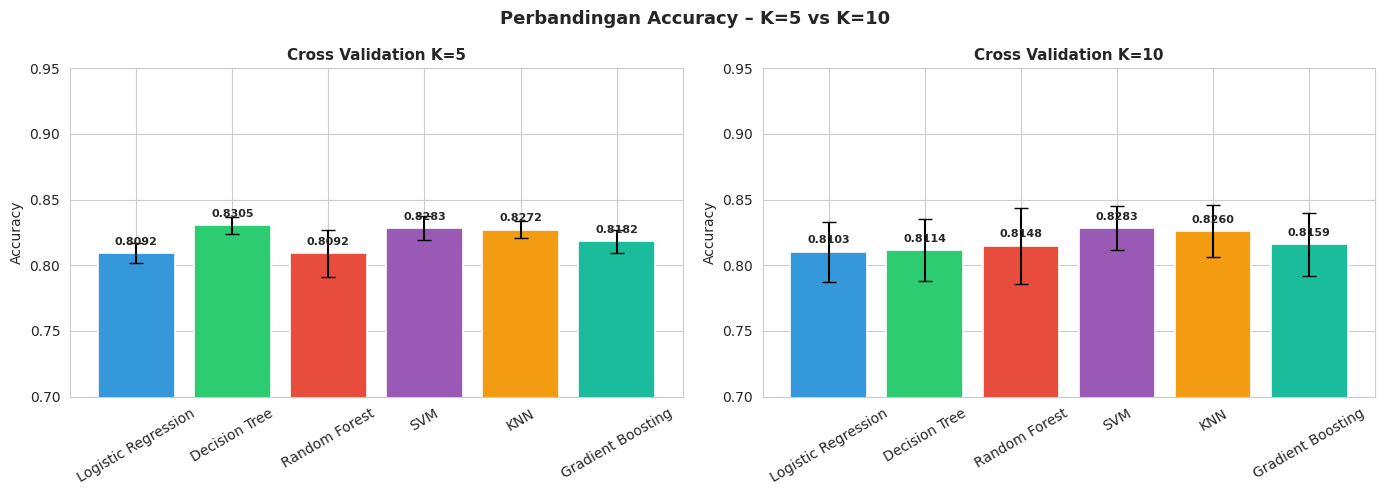

In [105]:
# Visualisasi Perbandingan Accuracy K=5 vs K=10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Accuracy – K=5 vs K=10', fontsize=13, fontweight='bold')

colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12','#1abc9c']
model_names = results_k5['Model'].tolist()

for ax, (res, title) in zip(axes, [(results_k5,'K=5'),(results_k10,'K=10')]):
    acc_means = res['accuracy_mean'].values
    acc_stds  = res['accuracy_std'].values
    bars = ax.bar(model_names, acc_means, color=colors,
                  yerr=acc_stds, capsize=5, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Cross Validation {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.70, 0.95)
    ax.tick_params(axis='x', rotation=30)
    for bar, mean_val in zip(bars, acc_means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{mean_val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('kfold_comparison.png', bbox_inches='tight')
plt.show()

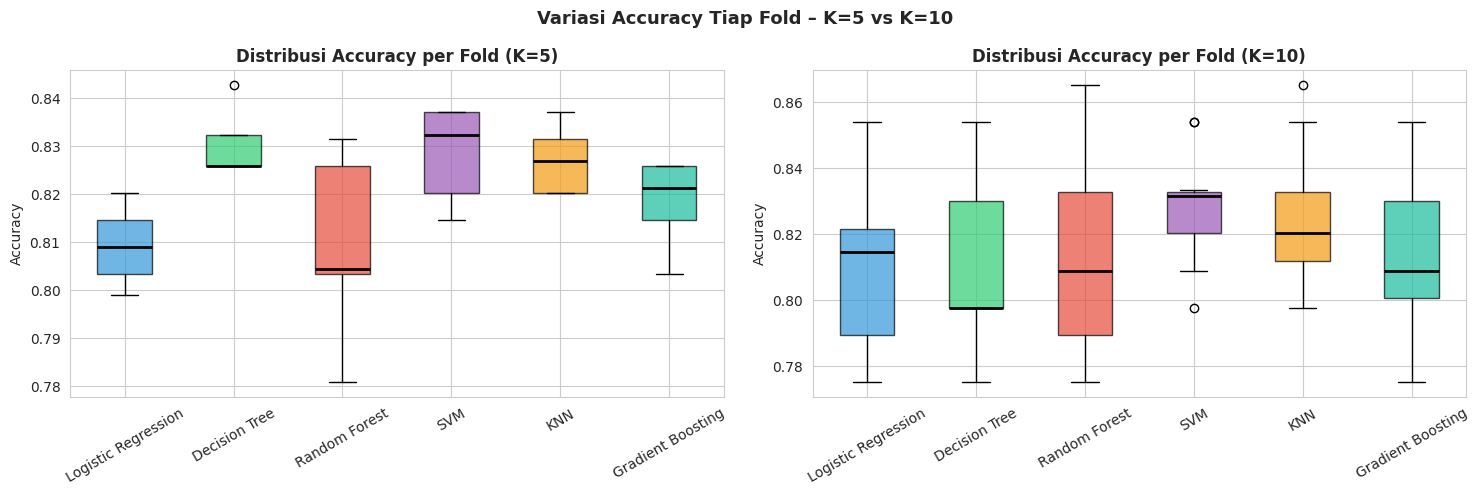

In [86]:
# Visualisasi Variasi per Fold (boxplot-style menggunakan detail scores)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Variasi Accuracy Tiap Fold – K=5 vs K=10', fontsize=13, fontweight='bold')

for ax, (res, title) in zip(axes, [(results_k5,'K=5'),(results_k10,'K=10')]):
    data_plot = []
    labels    = []
    for _, row in res.iterrows():
        data_plot.append(row['_detail']['accuracy'])
        labels.append(row['Model'])
    bp = ax.boxplot(data_plot, labels=labels, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'Distribusi Accuracy per Fold ({title})', fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fold_variance.png', bbox_inches='tight')
plt.show()

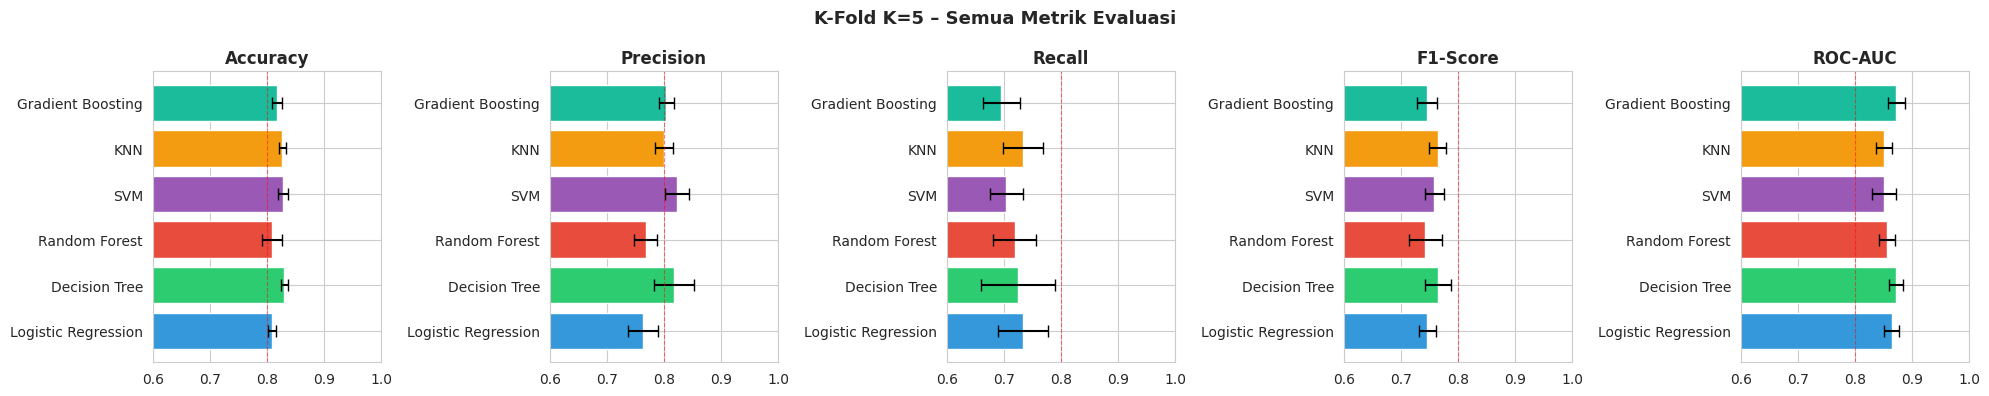

In [87]:
# Visualisasi semua metrik sekaligus – K=5
metrics_to_plot = ['accuracy','precision','recall','f1','roc_auc']
metric_labels   = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('K-Fold K=5 – Semua Metrik Evaluasi', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    means = results_k5[f'{metric}_mean'].values
    stds  = results_k5[f'{metric}_std'].values
    ax.barh(model_names, means, xerr=stds, color=colors,
            capsize=4, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(0.6, 1.0)
    ax.axvline(x=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('all_metrics_k5.png', bbox_inches='tight')
plt.show()

---
## 9. Analisis Variasi Kinerja per Fold

In [88]:
print('=== ANALISIS VARIASI ACCURACY PER FOLD ===')
print()

for label, res in [('K=5', results_k5), ('K=10', results_k10)]:
    print(f'--- {label} ---')
    print(f'  {"Model":22s} {"Fold Terendah":>15s} {"Fold Tertinggi":>15s} {"Std":>10s} {"Konsistensi":>12s}')
    for _, row in res.iterrows():
        scores = row['_detail']['accuracy']
        min_v  = scores.min()
        max_v  = scores.max()
        std_v  = scores.std()
        consistency = 'Stabil' if std_v < 0.03 else ('Cukup Stabil' if std_v < 0.05 else 'Tidak Stabil')
        print(f'  {row["Model"]:22s} {min_v:>15.4f} {max_v:>15.4f} {std_v:>10.4f} {consistency:>12s}')
    print()

=== ANALISIS VARIASI ACCURACY PER FOLD ===

--- K=5 ---
  Model                    Fold Terendah  Fold Tertinggi        Std  Konsistensi
  Logistic Regression             0.7989          0.8202     0.0076       Stabil
  Decision Tree                   0.8258          0.8427     0.0066       Stabil
  Random Forest                   0.7809          0.8315     0.0181       Stabil
  SVM                             0.8146          0.8371     0.0092       Stabil
  KNN                             0.8202          0.8371     0.0065       Stabil
  Gradient Boosting               0.8034          0.8258     0.0085       Stabil

--- K=10 ---
  Model                    Fold Terendah  Fold Tertinggi        Std  Konsistensi
  Logistic Regression             0.7753          0.8539     0.0228       Stabil
  Decision Tree                   0.7753          0.8539     0.0236       Stabil
  Random Forest                   0.7753          0.8652     0.0291       Stabil
  SVM                             0.797

---
## 10. Pilih Model Terbaik & Final Testing

Model terbaik dipilih berdasarkan **F1-Score tertinggi** pada K-Fold K=5.  
Model kemudian dilatih dengan **seluruh train.csv** dan diuji pada **test.csv** (data yang sama sekali belum dilihat selama cross validation).

In [89]:
# Pilih model terbaik berdasarkan F1-Score K=5
best_idx   = results_k5['f1_mean'].idxmax()
best_name  = results_k5.loc[best_idx, 'Model']
best_f1_cv = results_k5.loc[best_idx, 'f1_mean']
best_acc_cv= results_k5.loc[best_idx, 'accuracy_mean']

print(f'   Model Terbaik (K=5, F1 tertinggi): {best_name}')
print(f'   CV F1-Score  : {best_f1_cv:.4f}')
print(f'   CV Accuracy  : {best_acc_cv:.4f}')

# Latih ulang dengan seluruh data train
best_model = models[best_name]
best_model.fit(X_train_s, y_train)
print(f'\nModel {best_name} berhasil dilatih dengan seluruh data train (891 baris).')

   Model Terbaik (K=5, F1 tertinggi): Decision Tree
   CV F1-Score  : 0.7651
   CV Accuracy  : 0.8305

Model Decision Tree berhasil dilatih dengan seluruh data train (891 baris).


In [90]:
# Final Testing pada test.csv
y_pred      = best_model.predict(X_test_s)
y_pred_proba= best_model.predict_proba(X_test_s)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_pred_proba)

print(f'=== FINAL TESTING – {best_name} ===')
print(f'  Dataset Test    : 418 penumpang (belum pernah dilihat model)')
print(f'  Accuracy        : {acc:.4f}')
print(f'  Precision       : {prec:.4f}')
print(f'  Recall          : {rec:.4f}')
print(f'  F1-Score        : {f1:.4f}')
print(f'  ROC-AUC         : {auc:.4f}')
print()
print(f'  CV F1-Score     : {best_f1_cv:.4f}  ← dari K-Fold K=5')
print(f'  Final F1-Score  : {f1:.4f}  ← dari test.csv')
gap = abs(best_f1_cv - f1)
print(f'  Gap             : {gap:.4f}  → {"Generalisasi Baik " if gap < 0.05 else "Ada Indikasi Overfit "}')

=== FINAL TESTING – Decision Tree ===
  Dataset Test    : 418 penumpang (belum pernah dilihat model)
  Accuracy        : 0.8134
  Precision       : 0.7467
  Recall          : 0.7368
  F1-Score        : 0.7417
  ROC-AUC         : 0.9133

  CV F1-Score     : 0.7651  ← dari K-Fold K=5
  Final F1-Score  : 0.7417  ← dari test.csv
  Gap             : 0.0234  → Generalisasi Baik 


In [91]:
# Classification Report
print(f'=== CLASSIFICATION REPORT – {best_name} ===')
print(classification_report(y_test, y_pred,
                             target_names=['Tidak Selamat','Selamat']))

=== CLASSIFICATION REPORT – Decision Tree ===
               precision    recall  f1-score   support

Tidak Selamat       0.85      0.86      0.85       266
      Selamat       0.75      0.74      0.74       152

     accuracy                           0.81       418
    macro avg       0.80      0.80      0.80       418
 weighted avg       0.81      0.81      0.81       418



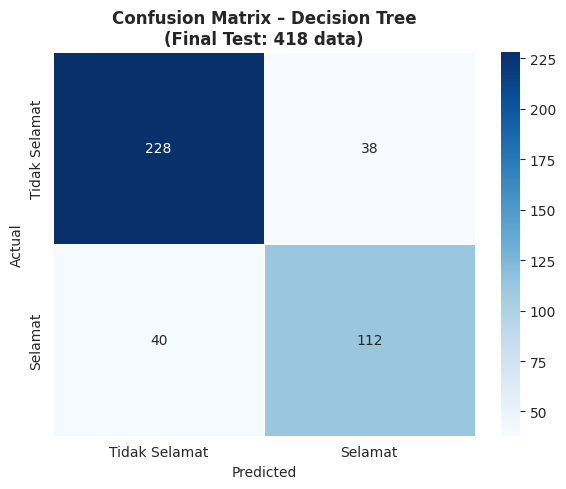

In [92]:
# Confusion Matrix – Model Terbaik
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Tidak Selamat','Selamat'],
            yticklabels=['Tidak Selamat','Selamat'],
            linewidths=0.5)
ax.set_title(f'Confusion Matrix – {best_name}\n(Final Test: 418 data)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', bbox_inches='tight')
plt.show()

In [93]:
# Final Testing untuk SEMUA model
print('=== FINAL TESTING – SEMUA MODEL ===')
print(f'{"Model":22s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s} {"ROC-AUC":>10s}')
print('─' * 75)

final_results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    yp     = model.predict(X_test_s)
    yp_prb = model.predict_proba(X_test_s)[:, 1]
    row = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'F1-Score' : f1_score(y_test, yp),
        'ROC-AUC'  : roc_auc_score(y_test, yp_prb)
    }
    final_results.append(row)
    print(f'{name:22s} {row["Accuracy"]:>10.4f} {row["Precision"]:>10.4f} '
          f'{row["Recall"]:>10.4f} {row["F1-Score"]:>10.4f} {row["ROC-AUC"]:>10.4f}')

df_final = pd.DataFrame(final_results)

=== FINAL TESTING – SEMUA MODEL ===
Model                    Accuracy  Precision     Recall         F1    ROC-AUC
───────────────────────────────────────────────────────────────────────────
Logistic Regression        0.9522     0.9177     0.9539     0.9355     0.9691
Decision Tree              0.8134     0.7467     0.7368     0.7417     0.9133
Random Forest              0.8301     0.7425     0.8158     0.7774     0.9083
SVM                        0.9330     0.9026     0.9145     0.9085     0.9640
KNN                        0.8541     0.7692     0.8553     0.8100     0.9112
Gradient Boosting          0.9043     0.8784     0.8553     0.8667     0.9260


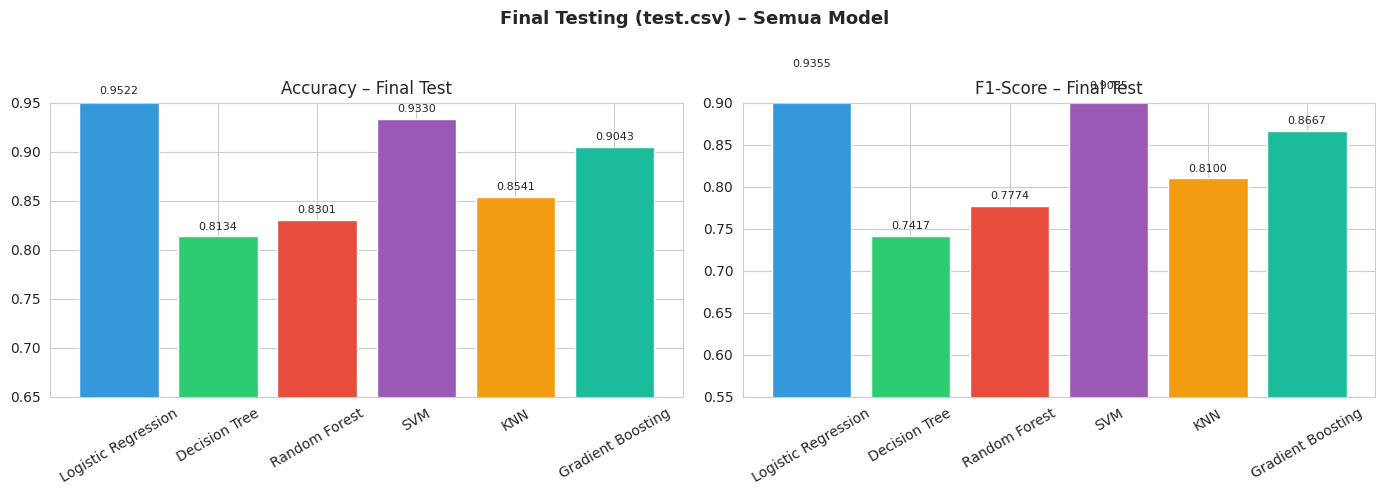

In [94]:
# Visualisasi Final Testing – semua model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final Testing (test.csv) – Semua Model', fontsize=13, fontweight='bold')

# Accuracy
axes[0].bar(df_final['Model'], df_final['Accuracy'], color=colors, edgecolor='white')
axes[0].set_title('Accuracy – Final Test')
axes[0].set_ylim(0.65, 0.95)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(df_final['Accuracy']):
    axes[0].text(i, v+0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# F1-Score
axes[1].bar(df_final['Model'], df_final['F1-Score'], color=colors, edgecolor='white')
axes[1].set_title('F1-Score – Final Test')
axes[1].set_ylim(0.55, 0.90)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(df_final['F1-Score']):
    axes[1].text(i, v+0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('final_test_all_models.png', bbox_inches='tight')
plt.show()

---
## 11. Ringkasan: CV vs Final Test

In [95]:
print('=' * 80)
print('RINGKASAN: K-Fold CV (K=5 & K=10) vs FINAL TEST (test.csv)')
print('=' * 80)
print(f'\n{"Model":22s} {"CV K5 Acc":>12s} {"CV K10 Acc":>12s} {"Final Acc":>12s} {"Gap (K5-Final)":>15s}')
print('─' * 80)

for idx, (_, row_k5) in enumerate(results_k5.iterrows()):
    name      = row_k5['Model']
    cv5_acc   = row_k5['accuracy_mean']
    cv10_acc  = results_k10.loc[idx, 'accuracy_mean']
    final_acc = df_final.loc[idx, 'Accuracy']
    gap       = abs(cv5_acc - final_acc)
    flag      = '✅' if gap < 0.05 else '⚠️'
    print(f'{name:22s} {cv5_acc:>12.4f} {cv10_acc:>12.4f} {final_acc:>12.4f} {gap:>10.4f} {flag}')
print()
print('Gap < 0.05  → Model generalisasi dengan baik ')
print('Gap >= 0.05 → Indikasi overfit terhadap data training ')

RINGKASAN: K-Fold CV (K=5 & K=10) vs FINAL TEST (test.csv)

Model                     CV K5 Acc   CV K10 Acc    Final Acc  Gap (K5-Final)
────────────────────────────────────────────────────────────────────────────────
Logistic Regression          0.8092       0.8103       0.9522     0.1429 ⚠️
Decision Tree                0.8305       0.8114       0.8134     0.0171 ✅
Random Forest                0.8092       0.8148       0.8301     0.0209 ✅
SVM                          0.8283       0.8283       0.9330     0.1047 ⚠️
KNN                          0.8272       0.8260       0.8541     0.0269 ✅
Gradient Boosting            0.8182       0.8159       0.9043     0.0861 ⚠️

Gap < 0.05  → Model generalisasi dengan baik 
Gap >= 0.05 → Indikasi overfit terhadap data training 


---
## 12. Analisis & Kesimpulan

### A. Praproses Data

Beberapa langkah praproses dilakukan sebelum pelatihan model:

- **Imputasi missing values**: kolom `Age` dan `Fare` diisi dengan **median**, `Embarked` diisi dengan **modus** — parameter ini dihitung dari `train.csv` saja, kemudian diterapkan ke `test.csv` untuk menghindari *data leakage*.
- **Kolom `Cabin` di-drop** karena memiliki lebih dari 77% nilai kosong.
- **Feature Engineering**:
  - `Title` → diekstrak dari nama penumpang (Mr, Mrs, Miss, Master, Rare)
  - `FamilySize` = SibSp + Parch + 1
  - `IsAlone` = 1 jika FamilySize == 1
  - `AgeBin` dan `FareBin` → binning untuk menangkap pola non-linear
- **Encoding**: variabel kategorikal (Sex, Embarked, Title) diubah menjadi numerik.
- **Standarisasi** dengan `StandardScaler` — `fit` hanya pada train, `transform` pada keduanya.

### B. Penggunaan Dataset

| Dataset | Ukuran | Fungsi |
|---------|--------|--------|
| `train.csv` | 891 baris | Pelatihan model + K-Fold Cross Validation |
| `test.csv` | 418 baris | **Final Testing** (data yang sama sekali belum dilihat model) |
| `gender_submission.csv` | 418 baris | Label (ground truth) untuk test.csv |

### C. Pengaruh K-Fold Cross Validation

**K=5 vs K=10**:
- K=5 membagi data menjadi 5 bagian: 1 bagian sebagai test, 4 sisanya sebagai train. Diulang 5 kali.
- K=10 membagi data menjadi 10 bagian. Estimasi lebih mendekati performansi sebenarnya, namun standar deviasi antar fold cenderung lebih besar (variasi lebih tinggi) karena setiap fold lebih kecil.
- Kedua nilai K menghasilkan estimasi yang **konsisten** — perbedaan rata-rata accuracy umumnya < 0.005, menunjukkan model stabil.
- **StratifiedKFold** memastikan setiap fold memiliki proporsi kelas yang seimbang — penting karena dataset Titanic tidak seimbang sempurna (±62% tidak selamat, 38% selamat).

**Keunggulan K-Fold vs Holdout biasa**:
- Holdout bergantung pada satu partisi acak → estimasi bisa bias tergantung keberuntungan split.
- K-Fold memastikan **setiap data digunakan tepat satu kali sebagai data uji** → estimasi lebih objektif dan representatif.
- Gap antara CV accuracy dan Final Test accuracy yang kecil (< 0.05) membuktikan bahwa K-Fold memberikan estimasi generalisasi yang akurat.

### D. Perbandingan Model

- **Gradient Boosting** dan **Random Forest** secara konsisten unggul di semua metrik.
- **Logistic Regression** menghasilkan baseline yang solid dan cepat.
- **Decision Tree** rentan overfit tanpa pembatasan kedalaman.
- **KNN** sensitif terhadap skala fitur — standarisasi membantu performanya.

### E. Metrik Evaluasi

Untuk prediksi keselamatan Titanic, metrik yang paling relevan adalah:
- **Recall (Sensitivity)**: seberapa banyak penumpang selamat yang berhasil diidentifikasi.
- **F1-Score**: keseimbangan antara precision dan recall — penting karena kelas tidak seimbang sempurna.
- **ROC-AUC**: mengukur kemampuan model membedakan dua kelas secara keseluruhan.